In [1]:
# imports
from __future__ import annotations
import os, sys
import pandas as pd
import importlib
import pyarrow.parquet as pq
import numpy as np
from dataclasses import dataclass
import datetime
# add the utils folder to my system path
sys.path.append(os.path.join(os.getcwd(), "utils"))
import utils
importlib.reload(utils)
import matplotlib.pyplot as plt
importlib.reload(utils)


<module 'utils' from 'c:\\Users\\sbramer\\HOME\\PROJECTS\\Hanford\\CodeReview\\TobitTrendAnalysis\\Tobit2.0\\utils\\utils.py'>

In [2]:
# input file paths
input_folder = r"input"
output_folder = r"output"
CR_TREND_PARQUET = os.path.join(input_folder, "Cr_TrendData", "Cr_TrendData.parquet")
WL_TRENDS_FLAT_CSV = os.path.join(input_folder, "WLTrends_flat.csv")

SYSTEM_WELLS_CSV = os.path.join(input_folder,"SystemWells.csv")
TREND_BREAKS_CSV = os.path.join(input_folder,"TrendBreaks_v051824.csv")
NO_RS_CSV = os.path.join(input_folder, "NoRS.csv")
KW_CSV = os.path.join(input_folder, "KW_selected_locations.csv")
RUM_CSV = os.path.join(input_folder, "list_RUM2_wells_and_beyond_v4_021225.csv")

## Run data prep
- load data(Chormium, Waterlevel Trends, CSV look-up tables)
- add *SYSTEM* from Systemwells.csv to chem data
- remove wells with no data in 2023
- create *TERM* Periods
  - TERM 1 - before cutoff
  - TERM 2 - after cutoff
  - remove empty TERMs
  - apply manual overrides from Trendbreaks.CSV
- build the list of wells where river stage should NOT be used
- extract lag values from water-level trends
- returns
  - chem_rs → the fully prepared chemistry dataset with TERM labels
  - ulags → dictionary of lag values per well
  - newrs_names → set of wells where river stage must be excluded

In [3]:
chem_rs, ulags, newrs_names = utils.run_script04_prep(CR_TREND_PARQUET, WL_TRENDS_FLAT_CSV, SYSTEM_WELLS_CSV, TREND_BREAKS_CSV, NO_RS_CSV, KW_CSV, RUM_CSV)

In [4]:
print("Prepared rows:", len(chem_rs))
print("Unique wells:", chem_rs["NAME"].nunique())
print("ULAG wells:", len(ulags))
print("NEWRS wells:", len(newrs_names))

Prepared rows: 4862430
Unique wells: 412
ULAG wells: 323
NEWRS wells: 74


## Run regression
- loop through each well
  - within well loop through TERMs
- build regression model:
- checks if the well is in the “no river stage” list
  - yes: log(VAL) ~ EVENT
  - no: log(VAL) ~ INTERP(river stage) + EVENT
- apply lag to river stage variable
- fit Tobit regression
- returns result as dataframe
  - One row per (well, TERM) containing:
    - model coefficients
    - lag used
    - number of observations
    - model statistics <u>not yet: p-values, AIC, BIC<\u>

In [5]:
results = utils.run_script04_models(chem_rs, ulags, newrs_names, min_n=8, max_pnd=0.5)
merged, summary = utils.compare_r_python_results(
    results,
    "R_CrTrends_complete_v6.csv",
    out_prefix="python_vs_r_tobit"
)
print(summary)

{'n_python': 733, 'n_r': 732, 'merge_counts': {'both': 732, 'left_only': 1, 'right_only': 0}, 'lag_n': 406, 'lag_match_rate': 1.0, 'LAG_mae': 0.0, 'p_trend_mae': 0.03962930720225848, 'AIC_mae': 2.0666662285551034, 'BIC_mae': 2.069613413366826, 'logLik_mae': nan, 'beta_intercept_mae': 15.258053558695764, 'beta_interp_mae': 0.08763817092161172, 'beta_event_mae': 6.200549622712292e-05, 'p_interp_mae': 0.15845821325495632, 'p_event_mae': 0.046422249958648715, 'n_obs_mae': nan}


## Compare the results
R vs Python

In [6]:
# results backup
ts = datetime.datetime.now().strftime("%Y%m%d_%H%M%S")
python_results_file = f"python_CrTrends_WLlag_byITER_{ts}.csv"
results.to_csv(os.path.join(output_folder, python_results_file), index=False)
merged.to_csv(os.path.join(output_folder, f"python_vs_r_tobit_diagnostics_merged_{ts}.csv"), index=False)

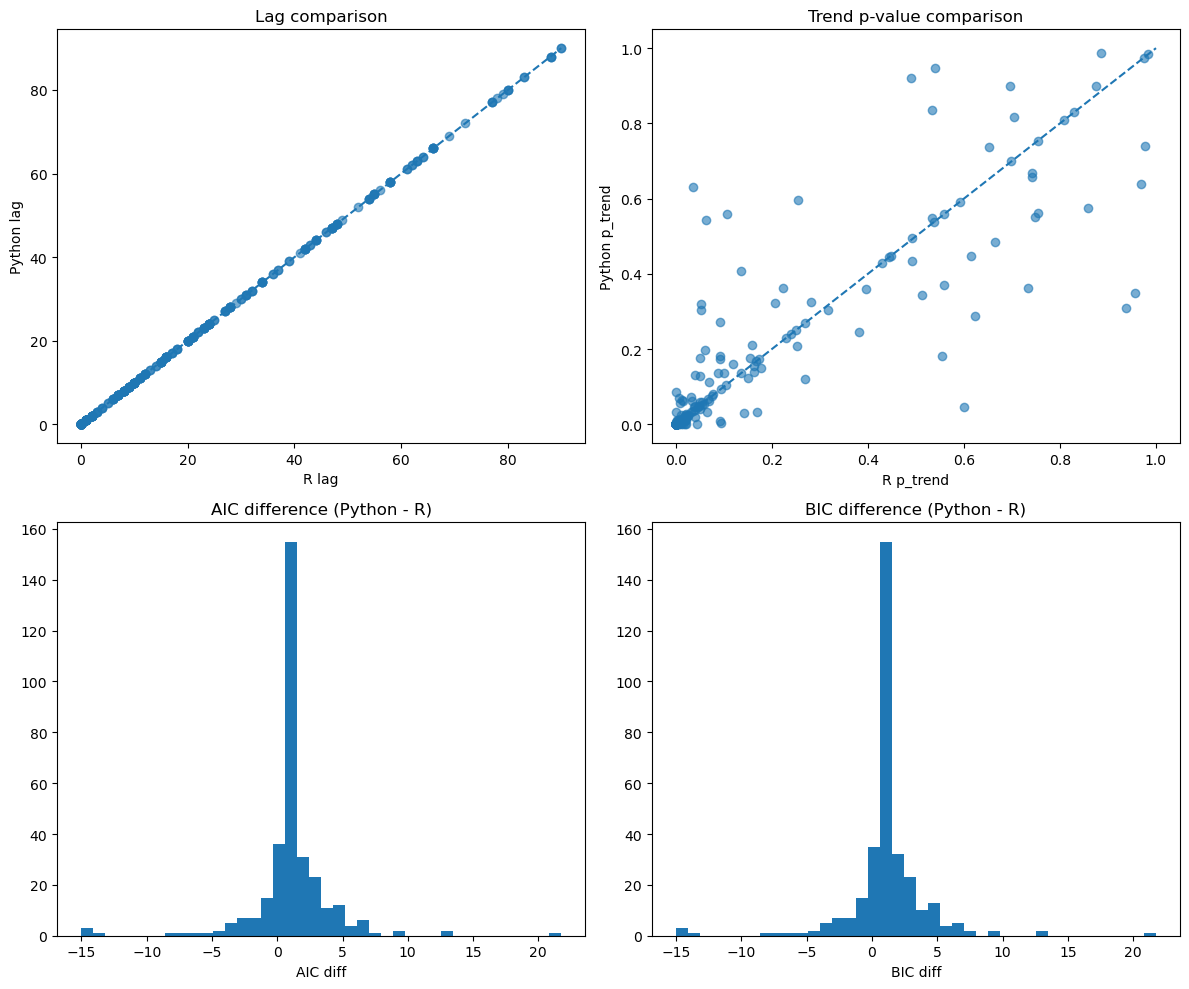

In [7]:
utils.plot_r_python_diagnostics(merged)

# inspect a mismatched fallback lag
m = merged[
    (merged["_merge"] == "both") &
    (merged["LAG_py"].notna()) &
    (merged["LAG_r"].notna()) &
    (merged["LAG_py"] != merged["LAG_r"])
]
if len(m):
    utils.plot_lag_trace(lag_diag, m.iloc[0]["KEY"])

In [9]:
# 199-D11-1
# 199-D2-10

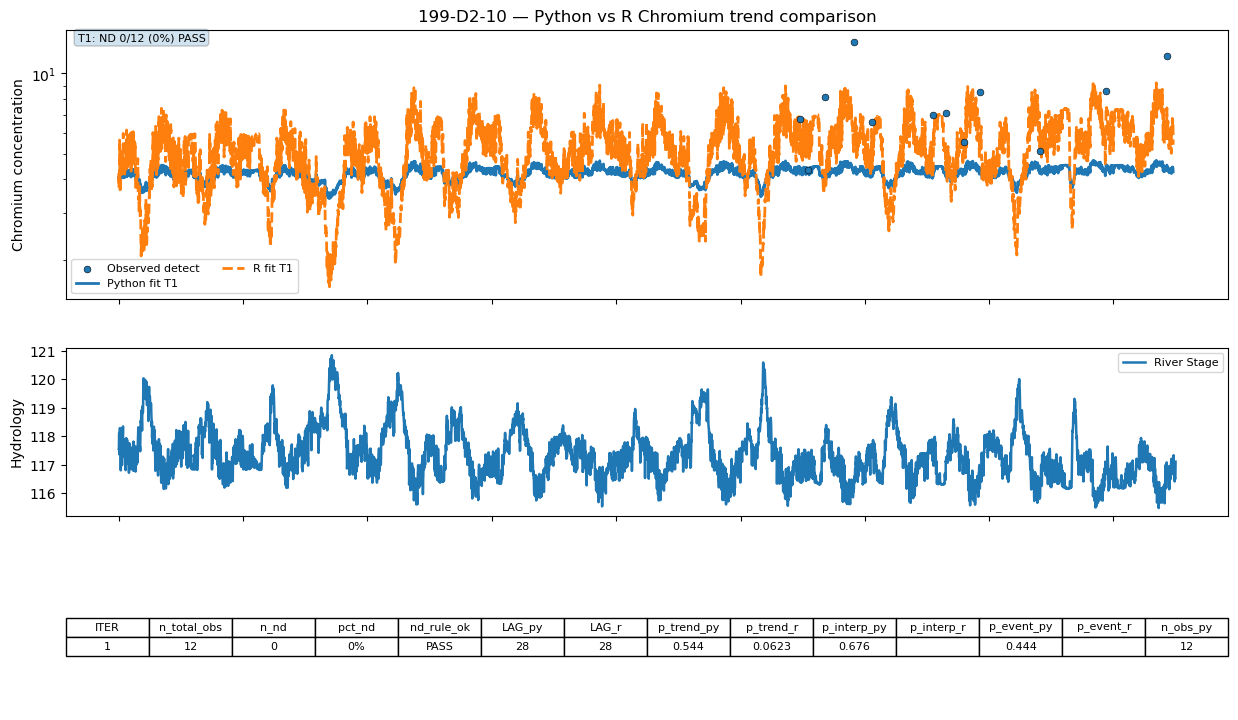

In [10]:
results_r = pd.read_csv("R_CrTrends_complete_v2.csv")

fig = utils.plot_well_trend_report(
    well="199-D2-10",
    chem_rs=chem_rs,
    results_py=results,
    results_r=results_r,
)

# Audit Table

In [6]:
import numpy as np
import pandas as pd
import utils


def pick_worst_keys(
    merged_csv: str,
    top_n: int = 10,
    prefer_fit_ok: bool = True,
) -> pd.DataFrame:
    """
    Rank keys by largest remaining mismatch.
    """
    cmp = pd.read_csv(merged_csv)

    # Keep only rows present in both
    cmp = cmp.loc[cmp["_merge"] == "both"].copy()

    # Optional: keep rows where Python fit succeeded
    if prefer_fit_ok and "fit_ok" in cmp.columns:
        cmp = cmp.loc[cmp["fit_ok"].fillna(False)].copy()

    # Absolute mismatch metrics
    for c in ["beta_interp_diff", "n_obs_diff", "p_interp_diff", "p_event_diff"]:
        if c in cmp.columns:
            cmp[f"abs_{c}"] = pd.to_numeric(cmp[c], errors="coerce").abs()

    sort_cols = [c for c in [
        "abs_beta_interp_diff",
        "abs_n_obs_diff",
        "abs_p_interp_diff",
        "abs_p_event_diff",
    ] if c in cmp.columns]

    if not sort_cols:
        raise ValueError("No mismatch columns found in merged comparison file.")

    return cmp.sort_values(sort_cols, ascending=False).head(top_n)


def build_script04_audit_table(
    key: str,
    chem_rs: pd.DataFrame,
    ulags: dict,
    newrs_names: set,
    max_lag: int = 90,
    min_n: int = 7,
    max_pnd: float = 1.0,
) -> pd.DataFrame:
    """
    Build a row-level audit table for one KEY = WELL__ITERn
    using the current Python Script 04 logic.
    """

    # ---- parse key ----
    if "__ITER" not in key:
        raise ValueError(f"KEY must look like WELL__ITERn, got: {key}")

    well, iter_txt = key.split("__ITER", 1)
    term = int(iter_txt)

    # ---- subset and sort exactly as model runner does ----
    g = chem_rs.loc[chem_rs["NAME"].astype(str) == str(well)].copy()
    if g.empty:
        raise ValueError(f"No rows found for well {well!r}")

    g["EVENT"] = pd.to_datetime(g["EVENT"]).dt.floor("D")
    g = g.sort_values(["EVENT", "_src_order"], kind="mergesort").copy()

    g_term = g.loc[g["TERM"].astype(int) == term].copy()
    if g_term.empty:
        raise ValueError(f"No rows found for {key}")

    g_term = g_term.sort_values(["EVENT", "_src_order"], kind="mergesort").reset_index(drop=True).copy()

    # ---- replicate current run_script04_models prep ----
    g_term["VAL"] = pd.to_numeric(g_term["VAL"], errors="coerce")
    g_term["INTERP"] = pd.to_numeric(g_term["INTERP"], errors="coerce")
    g_term["NDS"] = utils._bool_nds(g_term["NDS"]) if "NDS" in g_term else False

    # Values <= 0 cannot be logged
    g_term.loc[g_term["VAL"] <= 0, "VAL"] = np.nan
    g_term["Y"] = np.log(g_term["VAL"])

    # preserve original row position before lagging
    g_term["row_idx_before_lag"] = np.arange(len(g_term), dtype=int)

    use_rs = well not in newrs_names
    ulag = ulags.get(well, None)

    lag = np.nan
    lag_source = "NONE"
    lag_debug_table = pd.DataFrame()

    if use_rs:
        if ulag is None:
            lag, lag_debug_table = utils.estimate_lag_from_series_rstyle(
                event=g_term["EVENT"],
                dep=g_term["Y"],
                cov=g_term["INTERP"],
                nds=g_term["NDS"],
                max_lag=max_lag,
                min_n=min_n,
                max_pnd=max_pnd,
            )
            lag_source = "FALLBACK" if pd.notna(lag) else "NONE"
        elif pd.notna(ulag) and float(ulag) > 0:
            # current code still computes the fallback table for diagnostics,
            # then overrides with ULAG
            _, lag_debug_table = utils.estimate_lag_from_series_rstyle(
                event=g_term["EVENT"],
                dep=g_term["Y"],
                cov=g_term["INTERP"],
                nds=g_term["NDS"],
                max_lag=max_lag,
                min_n=min_n,
                max_pnd=max_pnd,
            )
            lag = int(round(float(ulag)))
            lag_source = "ULAG"
        else:
            lag = 0
            lag_source = "ULAG"
    else:
        # no-RS wells: EVENT-only model in your current runner
        lag = np.nan
        lag_source = "NO_RS"

    # ---- apply lag exactly like current Python model runner ----
    dt = g_term.copy()

    if use_rs:
        if pd.isna(lag):
            dt["INTERP_LAG"] = np.nan
        elif lag > 0:
            dt["INTERP_LAG"] = utils.lag_col_rstyle(dt["INTERP"], -int(lag))
        else:
            dt["INTERP_LAG"] = dt["INTERP"]
    else:
        dt["INTERP_LAG"] = np.nan

    # mark rows that survive the post-lag INTERP filter
    if use_rs and pd.notna(lag):
        if lag > 0:
            dt["survives_interp_lag_filter"] = dt["INTERP_LAG"].notna()
        else:
            dt["survives_interp_lag_filter"] = True
    else:
        dt["survives_interp_lag_filter"] = dt["Y"].notna()

    # build the final modelling frame exactly the way the current runner does
    if use_rs:
        if pd.notna(lag) and lag > 0:
            dt_model = dt.loc[dt["INTERP_LAG"].notna()].copy()
        else:
            dt_model = dt.copy()
    else:
        dt_model = dt.copy()

    dt_model = dt_model.reset_index(drop=True)
    dt_model["row_idx_after_lag"] = np.arange(len(dt_model), dtype=int)

    # stable event scale used in fitting
    if not dt_model.empty:
        dt_model["EVENT_NUM"] = (
            pd.to_datetime(dt_model["EVENT"]) - pd.to_datetime(dt_model["EVENT"]).min()
        ).dt.days / 365.25
    else:
        dt_model["EVENT_NUM"] = np.nan

    # current _run_tobit_rstyle uses x0 = df[df[y_col].notna()]
    dt_model["used_in_final_model"] = dt_model["Y"].notna()

   # ---- map final-model flags back to the full term table ----
    dt["row_idx_after_lag"] = np.nan
    dt["EVENT_NUM"] = np.nan
    dt["used_in_final_model"] = False

    if not dt_model.empty:
        # map surviving post-lag rows back by original row index
        idx_map = dict(
            zip(
                dt_model["row_idx_before_lag"].tolist(),
                dt_model["row_idx_after_lag"].tolist(),
            )
        )

        eventnum_map = dict(
            zip(
                dt_model["row_idx_before_lag"].tolist(),
                dt_model["EVENT_NUM"].tolist(),
            )
        )

        used_idx = set(
            dt_model.loc[dt_model["Y"].notna(), "row_idx_before_lag"].tolist()
        )

        dt["row_idx_after_lag"] = dt["row_idx_before_lag"].map(idx_map)
        dt["EVENT_NUM"] = dt["row_idx_before_lag"].map(eventnum_map)
        dt["used_in_final_model"] = dt["row_idx_before_lag"].isin(used_idx)

    # diagnostic boolean flags requested
    dt["has_y"] = dt["Y"].notna()
    dt["has_interp_lag"] = dt["INTERP_LAG"].notna()

    # add constant metadata
    dt["KEY"] = key
    dt["WELL"] = well
    dt["ITER"] = term
    dt["LAG"] = lag
    dt["lag_source"] = lag_source

    # final audit table in the order we want
    cols = [
        "KEY",
        "WELL",
        "ITER",
        "EVENT",
        "VAL",
        "Y",
        "NDS",
        "INTERP",
        "LAG",
        "INTERP_LAG",
        "has_y",
        "has_interp_lag",
        "used_in_final_model",
        "row_idx_before_lag",
        "row_idx_after_lag",
        "lag_source",
    ]

    # keep any other useful columns if they exist
    extras = [c for c in ["TERM", "SYSTEM", "DL", "MDL"] if c in dt.columns]
    audit = dt[cols + extras].sort_values(["EVENT", "row_idx_before_lag"]).reset_index(drop=True)

    return audit


def summarize_audit(audit: pd.DataFrame) -> dict:
    """
    Quick summary for one audit table.
    """
    out = {
        "key": audit["KEY"].iloc[0] if len(audit) else None,
        "n_term_rows": int(len(audit)),
        "n_has_y": int(audit["has_y"].sum()),
        "n_has_interp_lag": int(audit["has_interp_lag"].sum()),
        "n_used_in_final_model": int(audit["used_in_final_model"].sum()),
        "lag": audit["LAG"].iloc[0] if len(audit) else np.nan,
        "lag_source": audit["lag_source"].iloc[0] if len(audit) else None,
        "n_censored_in_final_model": int(
            audit.loc[audit["used_in_final_model"], "NDS"].fillna(False).astype(bool).sum()
        ),
    }
    return out

In [7]:
# 3) build one audit table
key = "199-D5-44__ITER1"   # replace if you want
audit = build_script04_audit_table(
    key=key,
    chem_rs=chem_rs,
    ulags=ulags,
    newrs_names=newrs_names,
    max_lag=90,
    min_n=7,
    max_pnd=1.0,
)

In [8]:
# print(utils.summarize_audit(audit))
# print(audit.to_string(index=False))
audit.to_csv(f"audit_{key.replace('__', '_')}.csv", index=False)

In [9]:
import inspect
import importlib
import numpy as np
import pandas as pd
import utils

print("utils file:", utils.__file__)

importlib.reload(utils)

print("\nlag_col_rstyle source:\n")
print(inspect.getsource(utils.lag_col_rstyle))

test = pd.Series([10, 20, 30, 40], dtype=float)
print("\nlag test input :", test.tolist())
print("lag test -2    :", utils.lag_col_rstyle(test, -2).tolist())
print("lag test +2    :", utils.lag_col_rstyle(test,  2).tolist())

utils file: c:\Users\sbramer\HOME\PROJECTS\Hanford\CodeReview\TobitTrendAnalysis\Tobit2.0\utils\utils.py

lag_col_rstyle source:

def lag_col_rstyle(x, lag=0):
    """
    Match extracted R lagCol(X, LAG) exactly.

    R behavior:
      if LAG == 0 or NA: return X
      if LAG < 0: prepend NAs, then take X[1:(n+LAG)]
      if LAG > 0: drop first LAG rows, append NAs
    """
    s = pd.Series(x).copy()
    n = len(s)

    if pd.isna(lag) or int(lag) == 0:
        return s

    lag = int(lag)

    if abs(lag) >= n:
        return pd.Series([np.nan] * n, index=s.index)

    if lag < 0:
        k = -lag
        vals = [np.nan] * k + s.iloc[: n - k].tolist()
    else:
        k = lag
        vals = s.iloc[k:].tolist() + [np.nan] * k

    return pd.Series(vals, index=s.index)


lag test input : [10.0, 20.0, 30.0, 40.0]
lag test -2    : [nan, nan, 10.0, 20.0]
lag test +2    : [30.0, 40.0, nan, nan]


In [3]:
import utils
import inspect

print(utils.__file__)
print(inspect.getsource(utils.lag_col_rstyle))

c:\Users\sbramer\HOME\PROJECTS\Hanford\CodeReview\TobitTrendAnalysis\Tobit2.0\utils\utils.py
def lag_col_rstyle(x, lag=0):
    """
    Match extracted R lagCol(X, LAG) exactly.

    R behavior:
      if LAG == 0 or NA: return X
      if LAG < 0: prepend NAs, then take X[1:(n+LAG)]
      if LAG > 0: drop first LAG rows, append NAs
    """
    s = pd.Series(x).copy()
    n = len(s)

    if pd.isna(lag) or int(lag) == 0:
        return s

    lag = int(lag)

    if abs(lag) >= n:
        return pd.Series([np.nan] * n, index=s.index)

    if lag < 0:
        k = -lag
        vals = [np.nan] * k + s.iloc[: n - k].tolist()
    else:
        k = lag
        vals = s.iloc[k:].tolist() + [np.nan] * k

    return pd.Series(vals, index=s.index)

